In [5]:
from src.thunder.scripts.test_multiple import EmbeddingsInstanceDataset, InstanceLearner
from typing import List, Tuple
import re
import os
import torch
import numpy as np


N = 10000
MAX_EPOCHS = 50
WEIGHT_DECAY = 0.05
LR = 1e-4
WARMUP = int(0.1 * MAX_EPOCHS)
N_RUNS = 100
NAMES = ["conch", "uni", "uni2h", "clipvitbasepatch32"]
EMBED = [512, 1024, 1536, 512]

In [12]:
path_ = "/Users/miguelmartins/Projects/thunder-identifiable/logs"
model_ = "clipvitbasepatch32_2025-09-30_17-52-18"


def load_projector(path_, model_, version, sub_id):
    # log_path = f"{path_}/{model_}/version_{version}/{sub_id}"
    log_path = f"{path_}/{model_}/version_{version}"
    linear_projector = torch.nn.Linear(EMBED[0], N, bias=False)
    ckpt_path = f"{log_path}/checkpoints"
    checkpoint = os.listdir(ckpt_path)[0]
    ckpt = torch.load(f"{ckpt_path}/{checkpoint}")
    w = ckpt["state_dict"]["linear_projector.weight"]
    linear_projector.weight.data = w
    return w.cpu().numpy()

In [15]:
all_models = os.listdir(path_)
version = 0
sub_id = 0

projector_dict = {m: load_projector(path_, m, version, sub_id) for m in all_models}


In [16]:
for x in projector_dict:
    print(x)

clipvitbasepatch32_2025-09-30_17-52-18
conch_2025-09-30_17-52-20
uni_2025-09-30_17-52-19
uni2h_2025-09-30_17-52-20


In [20]:
import matplotlib.pyplot as plt 


Resolved 187 packages in 458ms                                       
Audited 162 packages in 0.07ms                                       


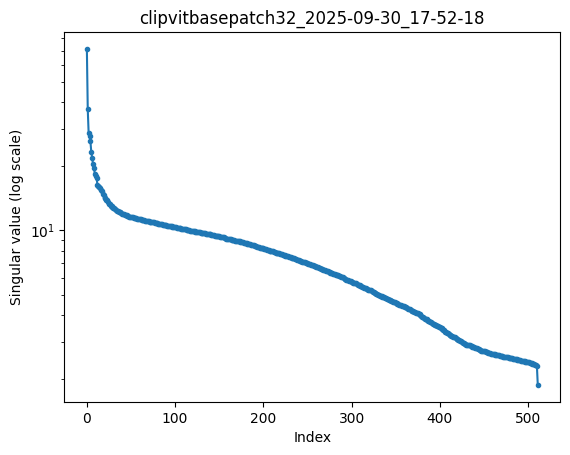

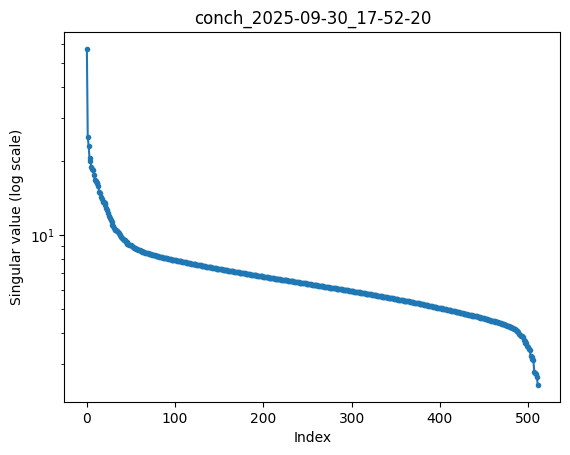

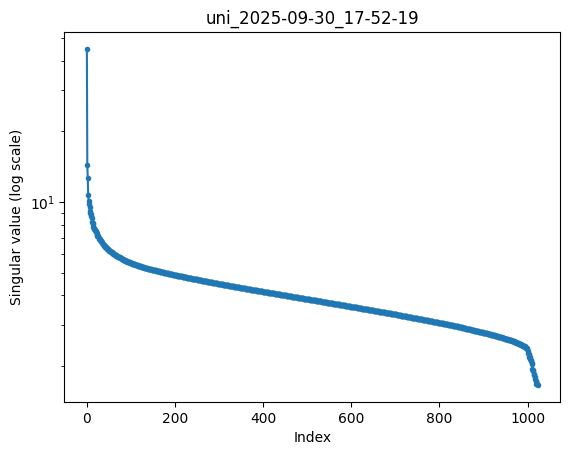

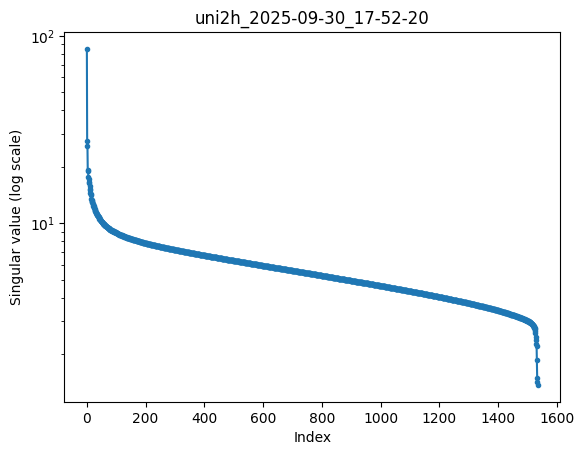

In [31]:
diagnostics = {}
for m, W in projector_dict.items():
    # Direct singular values of the operator
    S = np.linalg.svd(W, compute_uv=False)  # or scipy.linalg.svdvals(W)

    # Basic diagnostics
    cond = (S.max() / S.min()) if S.min() > 0 else np.inf
    eff_rank = np.exp(-np.sum(p := (S / S.sum())) * np.log(p + 1e-12))  # entropy-based effective rank

    plt.figure()
    plt.semilogy(S, marker='.')
    diagnostics[m] = [cond, eff_rank]
    plt.title(m)
    plt.xlabel("Index")
    plt.ylabel("Singular value (log scale)")
    plt.show()

In [35]:
[np.sum(diagnostics[m][1]) for m in diagnostics]

[np.float32(365664.97),
 np.float32(296219.5),
 np.float32(1151815.2),
 np.float32(2683242.2)]

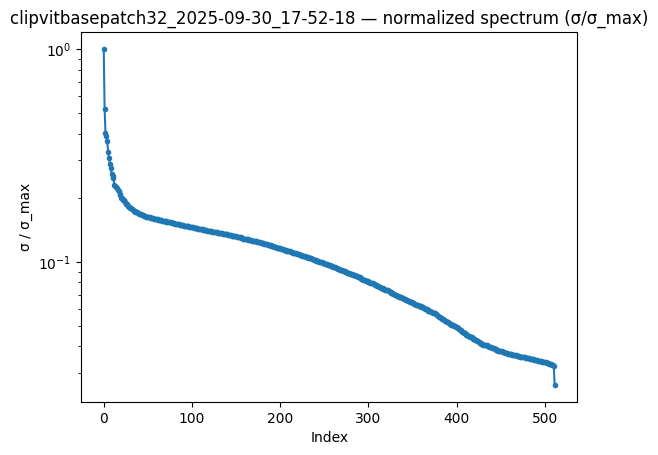

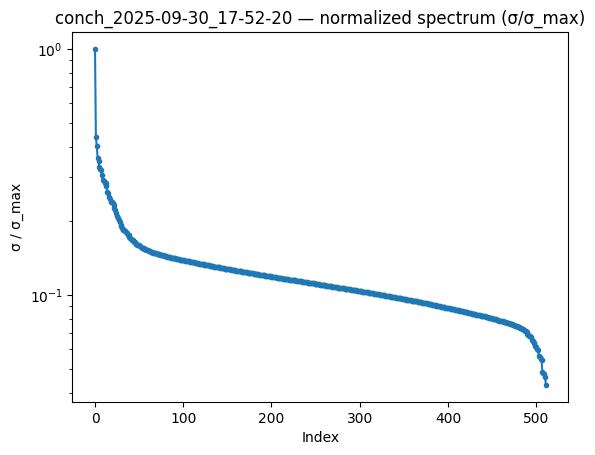

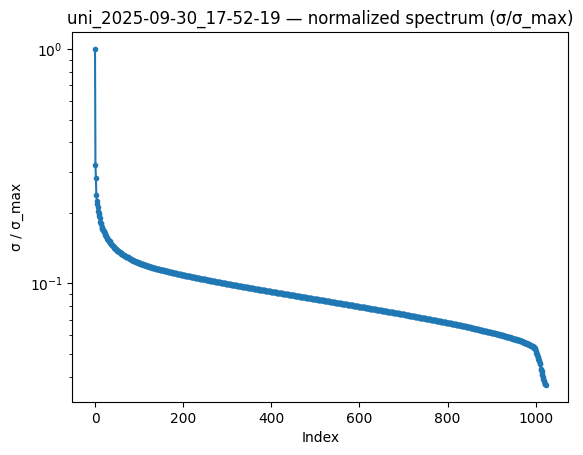

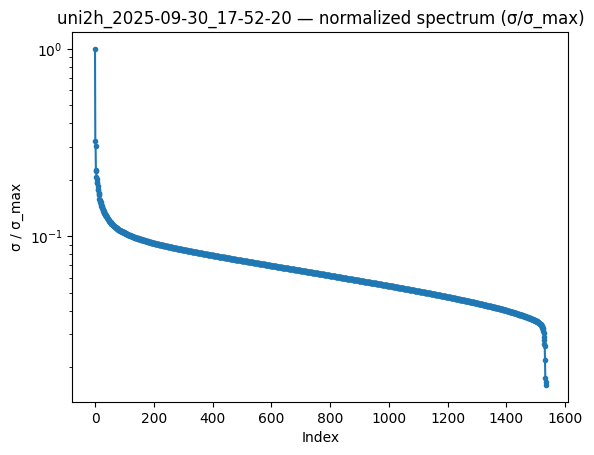

clipvitbasepatch32_2025-09-30_17-52-18  cond=37.89   eff_rank=431.0    eff_rank/embedding_dim=0.8 
conch_2025-09-30_17-52-20  cond=23.25   eff_rank=470.0    eff_rank/embedding_dim=0.9 
uni_2025-09-30_17-52-19  cond=27.08   eff_rank=963.0    eff_rank/embedding_dim=0.9 
uni2h_2025-09-30_17-52-20  cond=62.07   eff_rank=1415.3    eff_rank/embedding_dim=0.9 


In [45]:
import numpy as np
import matplotlib.pyplot as plt

diagnostics = {}
for m, W in projector_dict.items():
    # singular values
    S = np.linalg.svd(W, full_matrices=False, compute_uv=False).astype(np.float64)
    # condition number
    smin = S.min()
    cond = (S.max() / smin) if smin > 0 else np.inf

    # entropy-based effective rank (Roy & Vetterli)
    p = S / S.sum()
    H = -np.sum(p * np.log(p + 1e-12))   # Shannon entropy (nats)
    eff_rank = np.exp(H)                 # effective rank (scalar)

    diagnostics[m] = {"cond": float(cond), "eff_rank": float(eff_rank), "norm_eff_rank": float(eff_rank) / S.shape[0]}

    # plots: raw spectrum and scale-free normalized spectrum
    #plt.figure()
    #plt.semilogy(S, marker='.')
    #plt.title(f"{m} — spectrum (cond={cond:.2f}, eff_rank={eff_rank:.1f})")
    #plt.xlabel("Index"); plt.ylabel("Singular value (log scale)")
    #plt.show()

    plt.figure()
    plt.semilogy(S / S[0], marker='.')
    plt.title(f"{m} — normalized spectrum (σ/σ_max)")
    plt.xlabel("Index"); plt.ylabel("σ / σ_max")
    plt.show()

# Optional: print a compact table
for m, d in diagnostics.items():
    print(f"{m:20s}  cond={d['cond']:.2f}   eff_rank={d['eff_rank']:.1f}    eff_rank/embedding_dim={d['norm_eff_rank']:.1f} ")

In [40]:
431 / 512

0.841796875

In [41]:
470 / 512

0.91796875